In [ ]:
import numpy as np
from monodromy.haar import expected_cost
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.isa import expected_sentence_length
from gulps.utils.visualize import render_path

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

In [51]:
from gulps.utils.logging_config import logger

logger.setLevel("INFO")
# logger.setLevel("DEBUG")

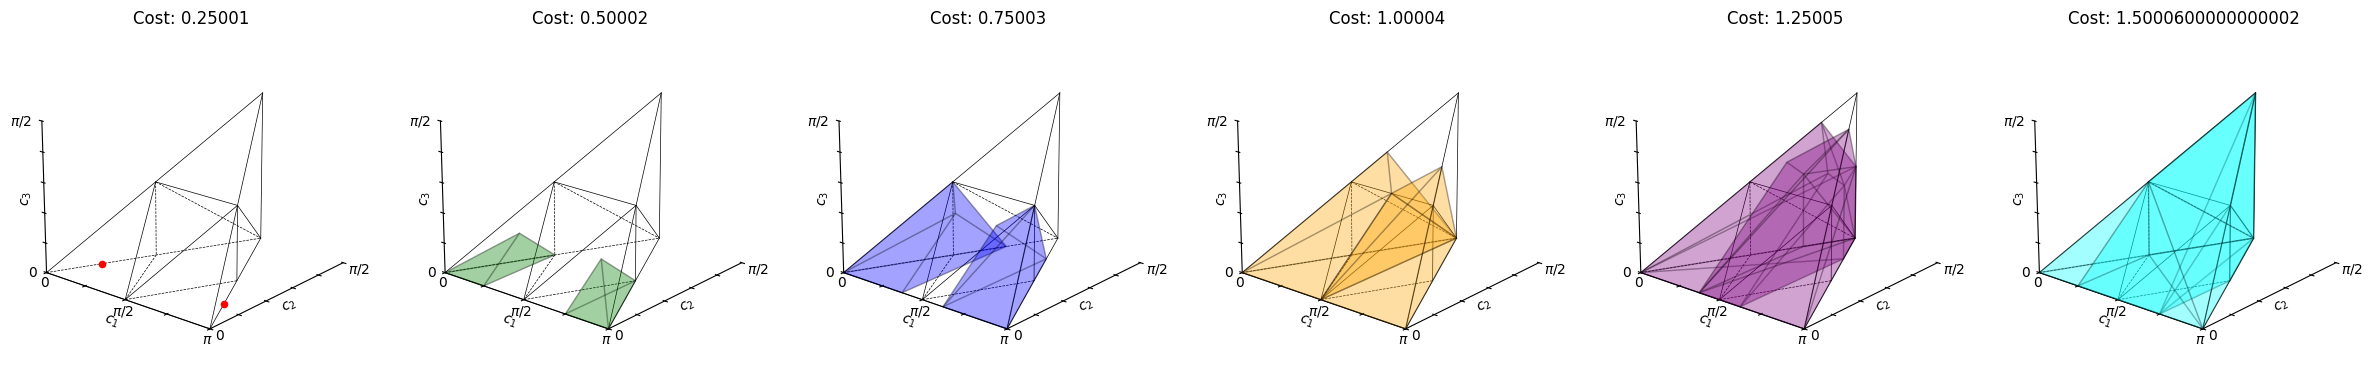

0.9599320617283754
3.8395746639269444


In [ ]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_haar_and_depth(decomposer.isa.coverage_set))

In [3]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    (CXGate(), 1.0, "cx"),
    (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

In [5]:
logger.setLevel("INFO")
N = 1_000
fidelities = []

for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)

    if fid < 1 - 1e-6:
        print(f"Unitary {idx} fidelity is low: {fid:.8f}")
        print("Canonical invariants:")
        print("U:", c1c2c3(u))
        print("V:", c1c2c3(v))
        print("\n")
        continue

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities)}")
print(f"  Mean fidelity:   {np.mean(fidelities)}")
print(f"  Minimum fidelity:{np.min(fidelities)}")

# print last timing dict
decomposer.last_timing

  0%|          | 0/1000 [00:00<?, ?it/s]

 88%|████████▊ | 878/1000 [00:32<00:05, 22.38it/s]

Unitary 876 fidelity is low: 0.99999556
Canonical invariants:
U: (np.float64(0.55634895), np.float64(0.35503494), np.float64(0.20690212))
V: (np.float64(0.55664498), np.float64(0.35384283), np.float64(0.2077616))




100%|██████████| 1000/1000 [00:38<00:00, 26.07it/s]


Summary across 1000 samples:
  Median fidelity: 1.0
  Mean fidelity:   0.9999999955083847
  Minimum fidelity:0.9999955636554247


{'lp': 0.0003538020000632969,
 'numeric': 0.013524493999739207,
 'stitch': 0.0010121450000042387}

In [7]:
logger.setLevel("DEBUG")
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)
u = random_unitary(4, seed=162)
v = Operator(decomposer(u))
average_gate_fidelity(u, v)

[gulps.gulps_decomposer] DEBUG: lp falls back to opposite rho_reflect
[gulps.local_numerics] DEBUG: [EASY 1/4] residual=[-1.44292396e-05 -1.46032299e-04 -4.71666060e-05] (‖residual‖=1.19e-08, nfev=256)
[gulps.local_numerics] DEBUG: [EASY 2/4] residual=[-2.89205156e-06 -2.77319733e-05 -1.06911821e-05] (‖residual‖=4.46e-10, nfev=256)
[gulps.local_numerics] DEBUG: [EASY 3/4] residual=[-1.82125296e-05 -2.37248464e-04 -5.57385226e-05] (‖residual‖=2.99e-08, nfev=256)
[gulps.local_numerics] DEBUG: [EASY 4/4] residual=[-6.61458476e-05 -9.64443073e-04 -2.05819636e-04] (‖residual‖=4.88e-07, nfev=256)
[gulps.local_numerics] DEBUG: [HARD 1/8] residual=[-1.49880108e-15 -1.89639970e-14 -4.44089210e-15] (‖residual‖=1.91e-28, nfev=2048)
[gulps.local_numerics] DEBUG: => Success on [HARD 1] (componentwise |residual| ≤ 5.0e-07)
[gulps.local_numerics] DEBUG: ✅ LM synthesis SUCCESS on HARD attempt 1 (residual=1.91e-28, total_nfev=3072) in 0.110s
[gulps.local_numerics] DEBUG: [EASY 1/4] residual=[-6.2508885

0.9999999999866276